Tên: Võ Quỳnh Nhi
MSSV: 056306001950
# ENSEMBLE LEARNING HOMEWORK
## 1. Làm sạch và định dạng dữ liệu (Data cleaning and Formatting)
### 1.1 Đọc dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier

from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
import xgboost as xgb
# import lightgbm as lgb
# from catboost import CatBoostClassifier

from sklearn.ensemble import StackingClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
train_df = pd.read_csv(r"c:\Users\AD\Documents\mliot-pyml-2026-hw\week06\Homework_11\train.csv")
test_df = pd.read_csv(r"c:\Users\AD\Documents\mliot-pyml-2026-hw\week06\Homework_11\test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (8693, 14)
Test shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### 1.2. Kiểm tra dữ liệu

In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


### 1.3 Kiểm tra dữ liệu thiếu

Tỷ lệ missing values:
 CryoSleep       2.496261
ShoppingMall    2.392730
VIP             2.335212
HomePlanet      2.312205
Name            2.300702
Cabin           2.289198
VRDeck          2.162660
FoodCourt       2.105142
Spa             2.105142
Destination     2.093639
RoomService     2.082135
Age             2.059128
dtype: float64


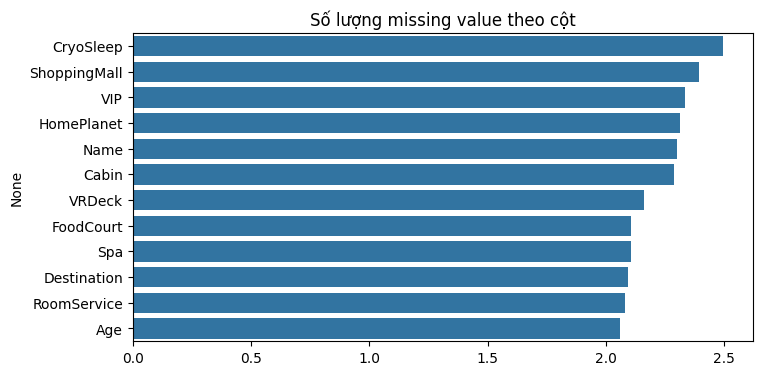

In [4]:
missing = (train_df.isnull().sum() / len(train_df)) * 100
missing = missing[missing > 0].sort_values(ascending=False)
print("Tỷ lệ missing values:\n", missing)

# Biểu đồ missing values
plt.figure(figsize=(8,4))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Số lượng missing value theo cột")
plt.show()

Hầu hết cột đều thiếu dữ liệu ở nhẹ và khá đồng đều 2-2.5%. Có thể điền các giá thiếu bằng median/mode

## 2. Khám phá và phân tích dữ liệu (Exploratory data analysis - EDA)
### 2.1 Phân tích biến mục tiêu
Mục đích để kiểm tra xem có mất cân bằng lớp không. Vì nếu một lớp chiếm cao hơn thì accuracy dễ gây hiểu lầm, lúc đó cần thêm các metric khác F1/precision/recall

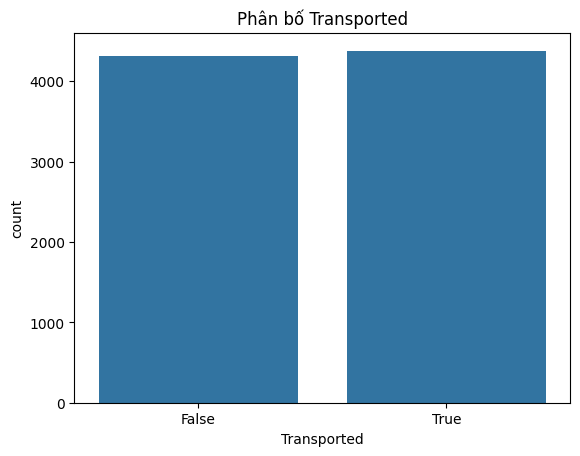

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

In [5]:
sns.countplot(x="Transported", data=train_df)
plt.title("Phân bố Transported")
plt.show()

train_df["Transported"].value_counts(normalize=True)

***Transported*** gần như cân bằng tuyệt đối - không cần xử lý imbalance

### 2.3 Phân tích các biến định tính

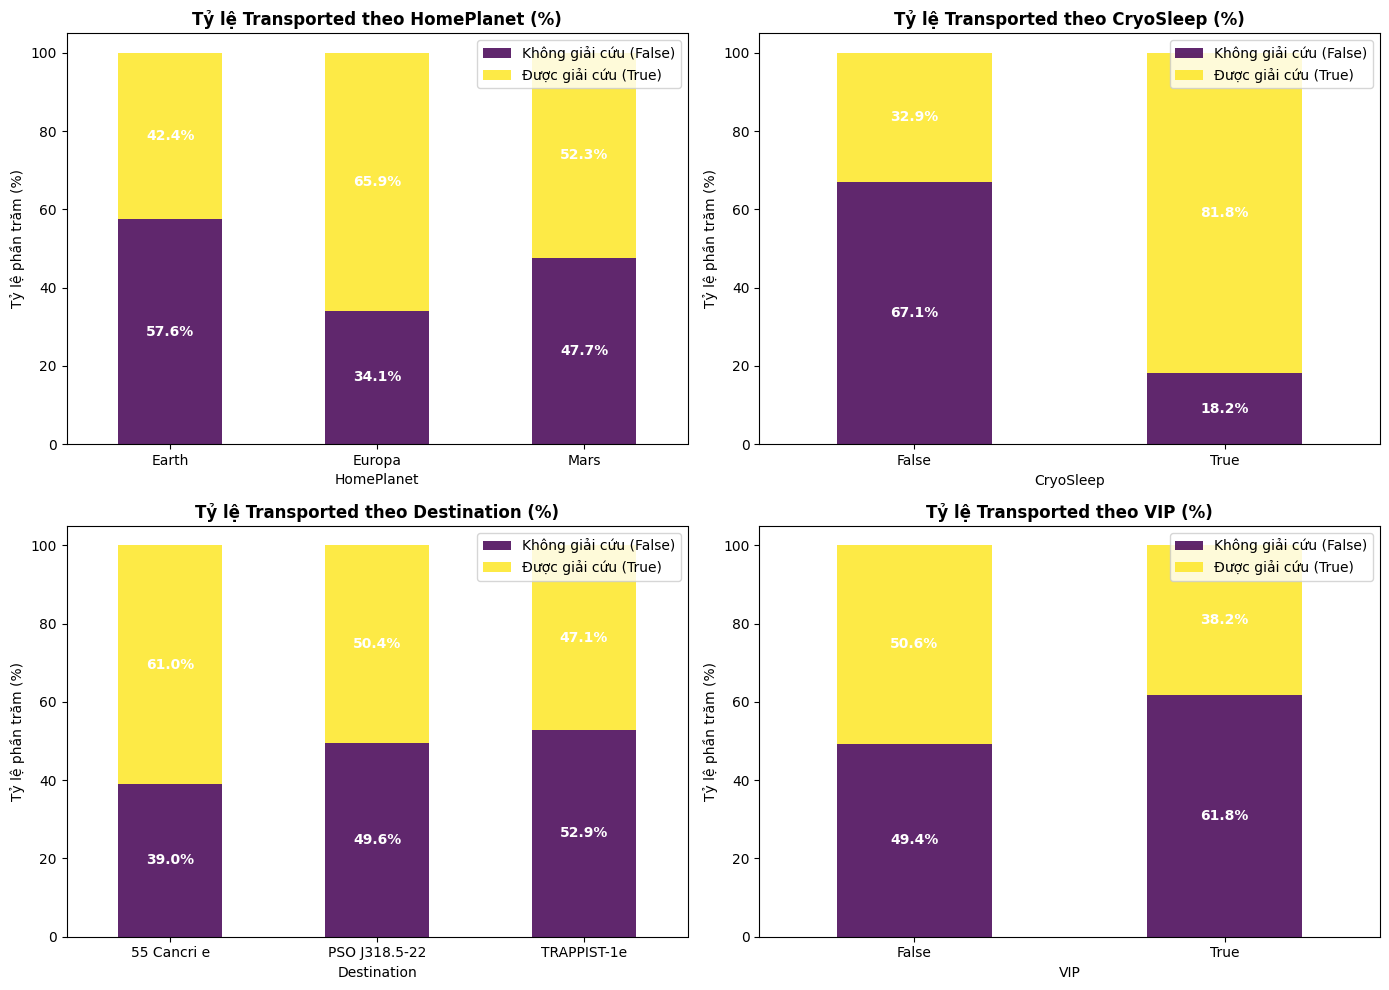

In [6]:
# Danh sách các biến định tính quan trọng cần phân tích
cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    # 1. Tính bảng tần suất tỷ lệ 
    prop_df = pd.crosstab(train_df[feature], train_df['Transported'], normalize='index') * 100
    
    # 2. Vẽ biểu đồ cột chồng tỷ lệ 100% 
    ax = prop_df.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', alpha=0.85)
    
    # 3. Hiển thị nhãn giá trị % trực tiếp trên từng cột
    for p in ax.patches:
        height = p.get_height()
        width = p.get_width()
        x, y = p.get_xy() 
        if height > 5: # hiển thị chữ nếu tỷ lệ > 5% để tránh đè chữ
            ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                    ha='center', va='center', color='white', fontweight='bold', fontsize=10)
            
    axes[i].set_title(f'Tỷ lệ Transported theo {feature} (%)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Tỷ lệ phần trăm (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].legend(['Không giải cứu (False)', 'Được giải cứu (True)'], loc='upper right')

plt.tight_layout()
plt.show()

* **CryoSleep (Rất quan trọng):** Nhóm ngủ đông có tỷ lệ được cứu cao vượt trội (81.8% so với 32.9%).
* **HomePlanet:** Hành khách từ Europa được cứu cao nhất (65.9%), Mars (52.3%), Earth thấp nhất (42.4%).
* **Destination:** Điểm đến 55 Cancri e có tỷ lệ cao hơn (61%), 2 điểm đến còn lại xấp xỉ 47–50%.
* **VIP (Ít giá trị):** Tỷ lệ giữa VIP và Không VIP gần như như nhau (~50.7%), có thể cân nhắc loại bỏ.

### 2.4 Phân tích các biến số

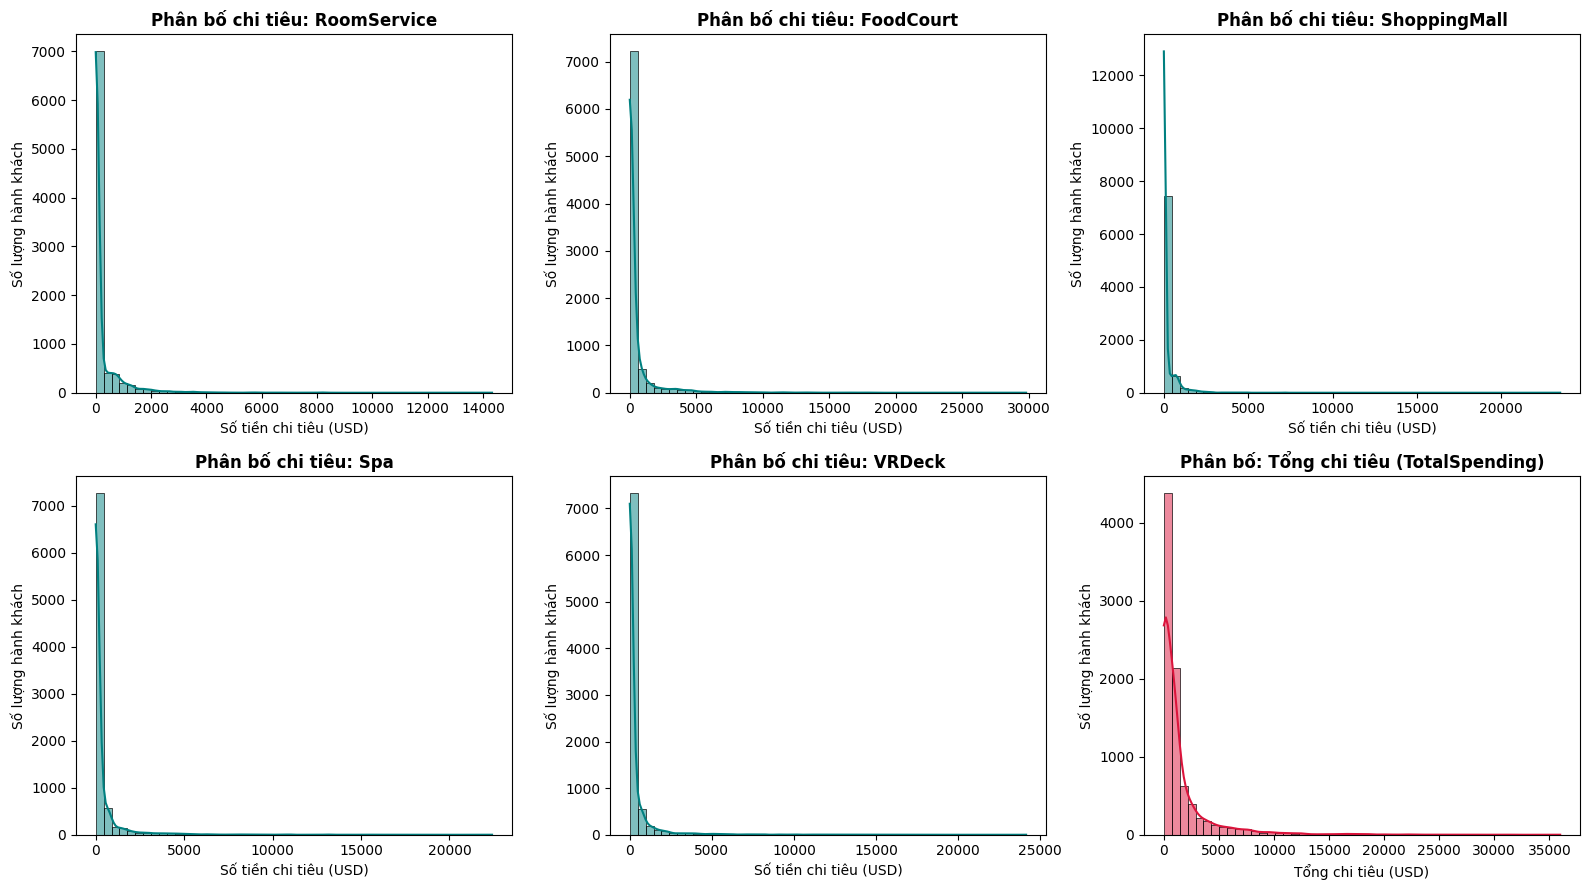

In [7]:
# Danh sách 5 cột chi tiêu
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 1. Biểu đồ Histogram trực tiếp trên dữ liệu gốc
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(spend_cols):
    # Vẽ Histogram với 50 thùng (bins) và đường ước lượng mật độ KDE
    sns.histplot(data=train_df, x=col, bins=50, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Phân bố chi tiêu: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Số tiền chi tiêu (USD)')
    axes[i].set_ylabel('Số lượng hành khách')

# Cột thứ 6: Biểu đồ phân bố cho Tổng chi tiêu (TotalSpending)
total_spend = train_df[spend_cols].fillna(0).sum(axis=1)
sns.histplot(total_spend, bins=50, kde=True, ax=axes[5], color='crimson')
axes[5].set_title('Phân bố: Tổng chi tiêu (TotalSpending)', fontsize=12, fontweight='bold')
axes[5].set_xlabel('Tổng chi tiêu (USD)')
axes[5].set_ylabel('Số lượng hành khách')

plt.tight_layout()
plt.show()

- Cả 5 biến chi tiêu đều bị lệch phải rất nặng
- Không nên điền missing value bằng Mean vì sẽ bị ảnh hưởng nghiêm trọng bởi các hành khách chi tiêu cực lớn (Outliers) -> Phương pháp phù hợp là dùng Median

## 3. Kỹ thuật tạo & lựa chọn đặc trưng (Feature engineering & selection)
Các thông tin bị giấu trong ***PassengerId***, ***Cabin***, ***Name*** và ***chi tiêu dịch vụ*** cần được trích xuất tối đa.
- Tách `Cabin` → `Deck`, `CabinNum`, `Side`
- Tách `PassengerId` → `Group`, tạo `GroupSize`
- Tạo `TotalSpend` = tổng 5 cột chi tiêu
- Xử lý missing `CryoSleep` dựa trên `TotalSpend`
- Encode biến phân loại, chuẩn hoá biến số

In [8]:
def feature_engineering(df):
    df_copy = df.copy()
    
    # 1. Tách PassengerId thành Group (Nhóm) và Member (Số thứ tự trong nhóm)
    df_copy[['Group', 'Group_num']] = df_copy['PassengerId'].str.split('_', expand=True)
    df_copy['Group'] = df_copy['Group'].astype(int)
    
    # Tính kích thước nhóm (GroupSize)
    group_sizes = df_copy['Group'].value_counts()
    df_copy['GroupSize'] = df_copy['Group'].map(group_sizes)
    df_copy['IsAlone'] = (df_copy['GroupSize'] == 1).astype(int)
    
    # 2. Tách Cabin thành Deck, Num, Side
    # Cabin dạng: Deck/Num/Side (VD: B/0/P)
    df_copy[['Cabin_deck', 'Cabin_num', 'Cabin_side']] = df_copy['Cabin'].str.split('/', expand=True)
    df_copy['Cabin_num'] = pd.to_numeric(df_copy['Cabin_num'], errors='coerce')
    
    # 3. Tạo tổng chi tiêu trên tàu (TotalSpending)
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    # Thay thế NaN tạm thời bằng 0 để tính tổng
    df_copy['TotalSpending'] = df_copy[spend_cols].fillna(0).sum(axis=1)
    df_copy['NoSpending'] = (df_copy['TotalSpending'] == 0).astype(int)
    
    # 4. Tách Họ (LastName) từ Name để nhận diện gia đình
    df_copy['LastName'] = df_copy['Name'].str.split(' ', expand=True)[1]
    
    return df_copy

# Áp dụng Feature Engineering cho cả Train và Test
df_train_fe = feature_engineering(train_df)
df_test_fe = feature_engineering(test_df)

In [9]:
# Tách biến mục tiêu Y và tập X
X = df_train_fe.drop(columns=['PassengerId', 'Name', 'Cabin', 'Transported', 'Group', 'LastName'])
y = df_train_fe['Transported'].astype(int)

X_test = df_test_fe.drop(columns=['PassengerId', 'Name', 'Cabin', 'Group', 'LastName'])

# Phân loại các cột đặc trưng
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending', 'Cabin_num', 'GroupSize']
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_deck', 'Cabin_side', 'IsAlone', 'NoSpending']

# Pipeline cho dữ liệu số: Điền missing value bằng Median + Chuẩn hóa StandardScaler
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline cho dữ liệu phân loại: Điền missing value bằng Mode + OneHotEncoder
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Gom lại bằng ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Transform dữ liệu
X_preprocessed = preprocessor.fit_transform(X)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"Kích thước X sau tiền xử lý: {X_preprocessed.shape}")

Kích thước X sau tiền xử lý: (8693, 33)


## 4. Thiết lập mô hình cơ sở (Baseline model)
Cần mô hình đơn lẻ để so sánh

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
dt_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Huấn luyện
dt_pipe.fit(X_train, y_train)

# Dự đoán
y_pred = dt_pipe.predict(X_val)

# Cross Validation
cv_scores = cross_val_score(
    dt_pipe,
    X_train,
    y_train,
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    ),
    scoring="accuracy"
)

# Lưu kết quả
results = []

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_val, y_pred),
    "Precision": precision_score(y_val, y_pred),
    "Recall": recall_score(y_val, y_pred),
    "F1": f1_score(y_val, y_pred),
    "CV_Mean": cv_scores.mean(),
    "CV_Std": cv_scores.std()
})

# Hiển thị bảng kết quả
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1,CV_Mean,CV_Std
0,Decision Tree,0.745831,0.754695,0.734018,0.744213,0.740583,0.011794


## 5. Bagging
- Huấn luyện nhiều mô hình con độc lập trên các tập con dữ liệu được lấy mẫu ngẫu nhiên có hoàn lại (bootstrap sampling), sau đó tổng hợp kết quả bằng vote/trung bình.


In [11]:
bag_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", BaggingClassifier(
        DecisionTreeClassifier(),
        n_estimators=500,
        max_samples=100,
        bootstrap=True,
        random_state=RANDOM_STATE
    ))
])

# Huấn luyện
bag_pipe.fit(X_train, y_train)

# Dự đoán
y_pred = bag_pipe.predict(X_val)

# Cross Validation
cv_scores = cross_val_score(
    bag_pipe,
    X,
    y,
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    ),
    scoring="accuracy"
)

# Lưu kết quả
results.append({
    "Model": "Bagging (Decision Tree)",
    "Accuracy": accuracy_score(y_val, y_pred),
    "Precision": precision_score(y_val, y_pred),
    "Recall": recall_score(y_val, y_pred),
    "F1": f1_score(y_val, y_pred),
    "CV_Mean": cv_scores.mean(),
    "CV_Std": cv_scores.std()
})

# Hiển thị bảng kết quả (Decision Tree + Bagging)
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1,CV_Mean,CV_Std
0,Decision Tree,0.745831,0.754695,0.734018,0.744213,0.740583,0.011794
1,Bagging (Decision Tree),0.787234,0.792148,0.783105,0.787600,0.794892,0.006456


## 6. Bootsting
- Huấn luyện tuần tự các bộ dự đoán, bộ dự đoán sau cố gắng sửa lỗi cho bộ dự đoán trước. Các thuật toán boosting phổ biến: **AdaBoost**, **Gradient Boosting**, và **XGBoost**
### 6.1 AdaBoost
- Bộ dự đoán sau có thể sửa lỗi cho bộ dự đoán trước là tập trung hơn vào các mẫu  huấn luyện mà bộ dự đoán trước bị dưới khớp. Điều này giúp bộ dự đoán sau chú ý vào những  trường hợp khó

In [12]:
ada_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=0.5,
        random_state=RANDOM_STATE
    ))
])

# Huấn luyện
ada_pipe.fit(X_train, y_train)

# Dự đoán trên tập validation (để so sánh với y_val)
y_pred_ada = ada_pipe.predict(X_val)

# Cross Validation
cv_scores = cross_val_score(
    ada_pipe,
    X,
    y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy"
)

# Lưu kết quả
results.append({
    "Model": "AdaBoost",
    "Accuracy": accuracy_score(y_val, y_pred_ada),
    "Precision": precision_score(y_val, y_pred_ada),
    "Recall": recall_score(y_val, y_pred_ada),
    "F1": f1_score(y_val, y_pred_ada),
    "CV_Mean": cv_scores.mean(),
    "CV_Std": cv_scores.std()
})

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1,CV_Mean,CV_Std
0,Decision Tree,0.745831,0.754695,0.734018,0.744213,0.740583,0.011794
1,Bagging (Decision Tree),0.787234,0.792148,0.783105,0.787600,0.794892,0.006456
2,AdaBoost,0.768833,0.796250,0.727169,0.760143,0.769009,0.007558


### 6.2 Gradient Boosting
- Lần lượt thêm các bộ dự đoán vào ensemble, mỗi bộ sửa  lỗi cho bộ trước đó. Tuy nhiên, thay vì tác động vào trọng số của mẫu tại tất cả các vòng lặp  như AdaBoost, phương pháp này cố gắng khớp bộ dự đoán mới vào sai số phần dư (residual  error) của bộ dự đoán trước đó

In [13]:
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

# Huấn luyện
gb_pipe.fit(X_train, y_train)

# Dự đoán trên tập validation
y_pred_gb = gb_pipe.predict(X_val)

# Cross Validation
cv_scores = cross_val_score(
    gb_pipe,
    X,
    y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy"
)

# Lưu kết quả
results.append({
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_val, y_pred_gb),
    "Precision": precision_score(y_val, y_pred_gb),
    "Recall": recall_score(y_val, y_pred_gb),
    "F1": f1_score(y_val, y_pred_gb),
    "CV_Mean": cv_scores.mean(),
    "CV_Std": cv_scores.std()
})

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1,CV_Mean,CV_Std
0,Decision Tree,0.745831,0.754695,0.734018,0.744213,0.740583,0.011794
1,Bagging (Decision Tree),0.787234,0.792148,0.783105,0.787600,0.794892,0.006456
2,AdaBoost,0.768833,0.796250,0.727169,0.760143,0.769009,0.007558
3,Gradient Boosting,0.802185,0.794900,0.818493,0.806524,0.804785,0.007198


In [14]:
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ))
])

# Huấn luyện
xgb_pipe.fit(X_train, y_train)

# Dự đoán trên tập validation
y_pred_xgb = xgb_pipe.predict(X_val)

# Cross Validation
cv_scores = cross_val_score(
    xgb_pipe,
    X,
    y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy"
)

# Lưu kết quả
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_val, y_pred_xgb),
    "Precision": precision_score(y_val, y_pred_xgb),
    "Recall": recall_score(y_val, y_pred_xgb),
    "F1": f1_score(y_val, y_pred_xgb),
    "CV_Mean": cv_scores.mean(),
    "CV_Std": cv_scores.std()
})

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1,CV_Mean,CV_Std
0,Decision Tree,0.745831,0.754695,0.734018,0.744213,0.740583,0.011794
1,Bagging (Decision Tree),0.787234,0.792148,0.783105,0.787600,0.794892,0.006456
2,AdaBoost,0.768833,0.796250,0.727169,0.760143,0.769009,0.007558
3,Gradient Boosting,0.802185,0.794900,0.818493,0.806524,0.804785,0.007198
4,XGBoost,0.814836,0.814773,0.818493,0.816629,0.811113,0.007080


## 7. Stacking
Dùng dự đoán của nhiều mô hình gốc khác nhau (base learners) làm đầu vào cho một mô hình cấp 2 (meta-model) học cách kết hợp tối ưu. Vì các mô hình khác nhau (tree-based, linear) thường mắc lỗi không tương quan hoàn toàn, meta-model có thể học cách "tin tưởng" từng mô hình theo từng tình huống — thường vượt qua hiệu suất của từng mô hình gốc riêng lẻ.

Base learners: Random Forest, Gradient Boosting, Logistic Regression. Meta-model: Logistic Regression (đơn giản, tránh overfit ở tầng 2).

In [15]:
base_learners = [
    ("rf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
    ("gb", GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE)),
    ("lr", LogisticRegression(max_iter=1000)),
]

stack_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", StackingClassifier(
        estimators=base_learners,
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5
    ))
])

# Huấn luyện
stack_pipe.fit(X_train, y_train)

# Dự đoán
y_pred = stack_pipe.predict(X_val)

# Cross Validation
cv_scores = cross_val_score(
    stack_pipe,
    X,
    y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy"
)

# Lưu kết quả
results.append({
    "Model": "Stacking",
    "Accuracy": accuracy_score(y_val, y_pred),
    "Precision": precision_score(y_val, y_pred),
    "Recall": recall_score(y_val, y_pred),
    "F1": f1_score(y_val, y_pred),
    "CV_Mean": cv_scores.mean(),
    "CV_Std": cv_scores.std()
})

pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1,CV_Mean,CV_Std
0,Decision Tree,0.745831,0.754695,0.734018,0.744213,0.740583,0.011794
1,Bagging (Decision Tree),0.787234,0.792148,0.783105,0.787600,0.794892,0.006456
2,AdaBoost,0.768833,0.796250,0.727169,0.760143,0.769009,0.007558
3,Gradient Boosting,0.802185,0.794900,0.818493,0.806524,0.804785,0.007198
4,XGBoost,0.814836,0.814773,0.818493,0.816629,0.811113,0.007080
5,Stacking,0.806786,0.802013,0.818493,0.810169,0.805705,0.007577


## 8. Benchmark tổng hợp & nhận xét
Tổng hợp toàn bộ kết quả các mô hình baseline và ensemble để so sánh trực quan.

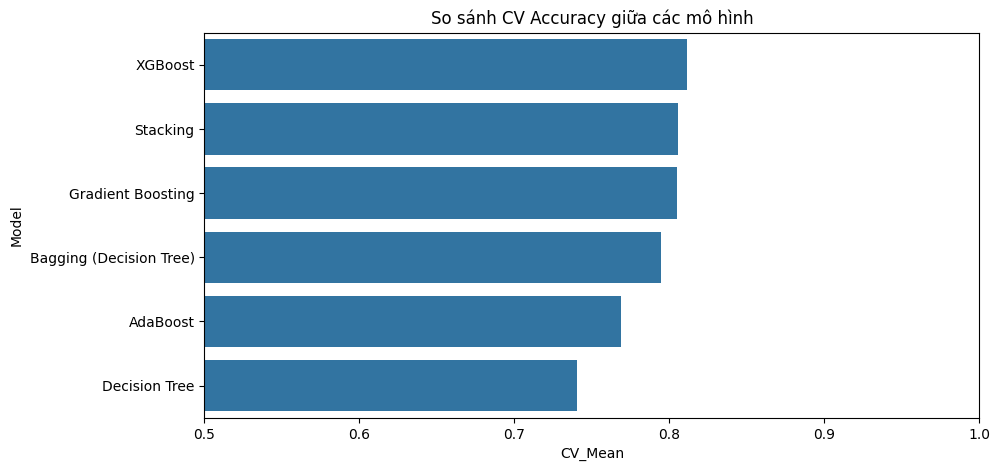

In [16]:
benchmark_df = pd.DataFrame(results).sort_values("CV_Mean", ascending=False).reset_index(drop=True)
benchmark_df

plt.figure(figsize=(10,5))
sns.barplot(x="CV_Mean", y="Model", data=benchmark_df)
plt.title("So sánh CV Accuracy giữa các mô hình")
plt.xlim(0.5, 1.0)
plt.show()


- **XGBoost**: đạt CV_Mean cao nhất (~0.81), vượt Decision Tree baseline gần 6 điểm phần trăm. XGBoost dẫn đầu vì kết hợp được cả hai cơ chế: giảm bias nhờ boosting tuần tự (mỗi cây sửa lỗi cây trước) và giảm variance nhờ subsample/colsample_bytree (mỗi cây chỉ dùng 80% dòng/cột, giống ý tưởng random subsampling của Bagging) — đây là lý do XGBoost thường vượt cả Gradient Boosting thuần lẫn Random Forest thuần trên hầu hết bài toán dạng bảng (tabular).
- **Boosting** nhìn chung mạnh hơn Bagging trên bộ dữ liệu này — cả XGBoost và Gradient Boosting đều vượt Bagging (Decision Tree). Điều này phù hợp với đặc điểm dữ liệu Spaceship Titanic: các biến có tương tác phi tuyến khá rõ (VD: CryoSleep gần như quyết định TotalSpend = 0, tổ hợp HomePlanet + Cabin_deck + Side cùng ảnh hưởng Transported). Boosting xây cây tuần tự, mỗi cây tập trung sửa đúng phần lỗi hệ thống còn sót lại, nên nắm bắt tốt các tương tác nhiều biến kiểu này hơn Bagging — nơi các cây độc lập, chỉ lấy trung bình mà không "học hỏi" lẫn nhau.
- **AdaBoost** là ngoại lệ đáng chú ý — dù cũng là Boosting nhưng lại thấp hơn cả Bagging (chỉ ~0.765, gần với Decision Tree đơn lẻ ~0.75). Lý do nằm ở cấu hình: AdaBoost dùng max_depth=1 (stump — cây chỉ chia 1 lần), trong khi dữ liệu này có tương tác đa biến khá phức tạp; một stump quá đơn giản để mỗi weak learner nắm được thông tin hữu ích, khiến AdaBoost không tận dụng được lợi thế boosting như Gradient Boosting/XGBoost (dùng max_depth=3 và max_depth=5). Đây cũng là điểm em có thể ghi vào phần hạn chế/hướng cải thiện ở mục 10 — thử tăng max_depth cho AdaBoost để so sánh công bằng hơn.
- **Decision Tree** đơn lẻ thấp nhất (~0.75) — đúng như kỳ vọng lý thuyết, vì đây là mô hình duy nhất không dùng kỹ thuật ensemble nào, dễ overfit trên tập train và có variance cao khi gặp dữ liệu mới.

## 9. Huấn luyện mô hình cuối & Dự đoán tập test
Chọn mô hình có `CV_Mean` cao nhất trong bảng benchmark, huấn luyện lại trên **toàn bộ** tập train (`X`, `y`), rồi dự đoán trên tập test của Kaggle.

In [18]:
# Chọn mô hình tốt nhất tự động từ bảng benchmark
best_model_name = benchmark_df.iloc[0]["Model"]
print(f"Mô hình tốt nhất theo CV_Mean: {best_model_name}")
print(f"CV_Mean: {benchmark_df.iloc[0]['CV_Mean']:.4f}")

# Đăng ký lại các pipeline CHƯA FIT, để huấn luyện sạch trên toàn bộ train
model_registry = {
    "Decision Tree": lambda: Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    "Bagging (Decision Tree)": lambda: Pipeline([
        ("preprocessor", preprocessor),
        ("model", BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                                     max_samples=100, bootstrap=True, random_state=RANDOM_STATE))
    ]),
    "AdaBoost": lambda: Pipeline([
        ("preprocessor", preprocessor),
        ("model", AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                      n_estimators=100, learning_rate=0.5, random_state=RANDOM_STATE))
    ]),
    "Gradient Boosting": lambda: Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                              max_depth=3, random_state=RANDOM_STATE))
    ]),
    "XGBoost": lambda: Pipeline([
        ("preprocessor", preprocessor),
        ("model", xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                                     subsample=0.8, colsample_bytree=0.8,
                                     random_state=RANDOM_STATE, eval_metric="logloss"))
    ]),
    "Stacking": lambda: Pipeline([
        ("preprocessor", preprocessor),
        ("model", StackingClassifier(estimators=base_learners,
                                      final_estimator=LogisticRegression(max_iter=1000), cv=5))
    ]),
}

final_model = model_registry[best_model_name]()
final_model.fit(X, y)  # huấn luyện trên TOÀN BỘ train data

print(f"Đã huấn luyện xong mô hình cuối cùng: {best_model_name}")


Mô hình tốt nhất theo CV_Mean: XGBoost
CV_Mean: 0.8111
Đã huấn luyện xong mô hình cuối cùng: XGBoost


In [19]:
# Dự đoán trên tập test chính thức
test_predictions = final_model.predict(X_test)
test_predictions_bool = test_predictions.astype(bool)

submission = pd.DataFrame({
    "PassengerId": df_test_fe["PassengerId"],
    "Transported": test_predictions_bool
})

submission.to_csv("submission.csv", index=False)
print("Đã lưu submission.csv —", len(submission), "dòng")
submission.head(10)

Đã lưu submission.csv — 4277 dòng


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
5,0027_01,False
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,True


In [21]:
# Kiểm tra phân bố dự đoán trên test (đối chiếu với phân bố train, phát hiện lệch bất thường)
print("Phân bố dự đoán trên test set:")
print(submission["Transported"].value_counts(normalize=True))
print()
print("Phân bố thực tế trên train set:")
print(df_train_fe["Transported"].value_counts(normalize=True))

results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model").sort_values("CV_Mean", ascending=False)
results_df

Phân bố dự đoán trên test set:
Transported
True     0.503156
False    0.496844
Name: proportion, dtype: float64

Phân bố thực tế trên train set:
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


,Accuracy,Precision,Recall,F1,CV_Mean,CV_Std
Model,,,,,,
XGBoost,0.814836,0.814773,0.818493,0.816629,0.811113,0.007080
Stacking,0.806786,0.802013,0.818493,0.810169,0.805705,0.007577
Gradient Boosting,0.802185,0.794900,0.818493,0.806524,0.804785,0.007198
Bagging (Decision Tree),0.787234,0.792148,0.783105,0.787600,0.794892,0.006456
AdaBoost,0.768833,0.796250,0.727169,0.760143,0.769009,0.007558
Decision Tree,0.745831,0.754695,0.734018,0.744213,0.740583,0.011794
